In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import argparse
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ======================
# ----- CONFIG ----------
# ======================
RESULTS_DIR = '/zhome/d0/a/221493/thesis/results'

In [18]:
CV_DIR   = os.path.join(RESULTS_DIR, 'C2_sim_cf/effusion/cv_results/cf_1')   # adjust
DISEASE  = 'effusion'
OUT_PATH = 'feature_group_comparison.csv'

In [19]:

# Load and concatenate all fold CSVs
fold_files = sorted([f for f in os.listdir(CV_DIR) if f.endswith('_predictions.csv')])
df = pd.concat([pd.read_csv(os.path.join(CV_DIR, f)) for f in fold_files], ignore_index=True)

print(f"Loaded {len(df):,} samples | Correct: {df['correct'].sum():,} | Incorrect: {(df['correct']==0).sum():,}")

# Identify feature groups — same logic as your pipeline
meta_cols  = {f'{DISEASE}_prob', f'{DISEASE}_pred', f'{DISEASE}_true',
              'correct', 'path', 'patient_id', 'cf_prob', 'cf_paths'}
model_cols = [c for c in df.columns if any(c.startswith(m) for m in ['LR_', 'RF_', 'MLP_'])]

delta_cols = [c for c in df.columns if c.startswith('delta_')]
emb_cols   = [c for c in df.columns if c.startswith('emb_')]
attr_cols  = [c for c in df.columns 
              if c not in meta_cols 
              and c not in model_cols
              and not c.startswith('delta_') 
              and not c.startswith('emb_')]

# Add the scalar meta-features that ARE part of M6 input
m6_scalars = [f'{DISEASE}_prob', 'cf_prob']

# All features we care about (M6 input, minus embeddings which are too many)
feature_cols = m6_scalars + attr_cols + delta_cols

print(f"\nFeature counts: prob+cf_prob={len(m6_scalars)}, attrs={len(attr_cols)}, deltas={len(delta_cols)}")


Loaded 97,705 samples | Correct: 81,174 | Incorrect: 16,531

Feature counts: prob+cf_prob=2, attrs=462, deltas=462


In [20]:
correct   = df[df['correct'] == 1]
incorrect = df[df['correct'] == 0]

In [21]:
# Summary stats
summary_correct = correct[feature_cols].describe().T[['mean', '50%', 'std']]
summary_incorrect = incorrect[feature_cols].describe().T[['mean', '50%', 'std']]

# Combine into one DataFrame for easier comparison
summary_df = pd.concat([summary_correct, summary_incorrect], axis=1)
summary_df.columns = ['mean_correct', 'median_correct', 'std_correct',
                      'mean_incorrect', 'median_incorrect', 'std_incorrect']

summary_df.to_csv('feature_group_comparison_stats.csv')
print(summary_df.head(10))

                           mean_correct  median_correct  std_correct  \
effusion_prob                  0.683049        0.709706     0.062132   
cf_prob                        0.610244        0.622828     0.053092   
margin                         0.061526        0.061316     0.029883   
age_pred                      59.064810       61.807919    13.326516   
sex_male                       0.576079        0.988792     0.482354   
sex_female                     0.423921        0.011208     0.482354   
race_white                     0.839825        0.996654     0.309992   
race_black                     0.088223        0.001046     0.233200   
race_asian                     0.071952        0.000240     0.214646   
Left Clavicle_area_pixels   2721.799111     2877.000000  1555.154033   

                           mean_incorrect  median_incorrect  std_incorrect  
effusion_prob                    0.616919          0.628199       0.059134  
cf_prob                          0.668049          0.

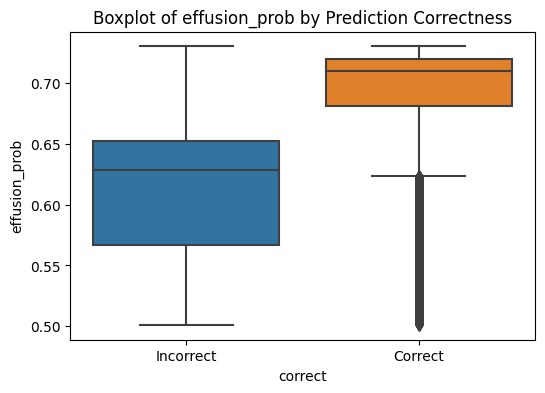

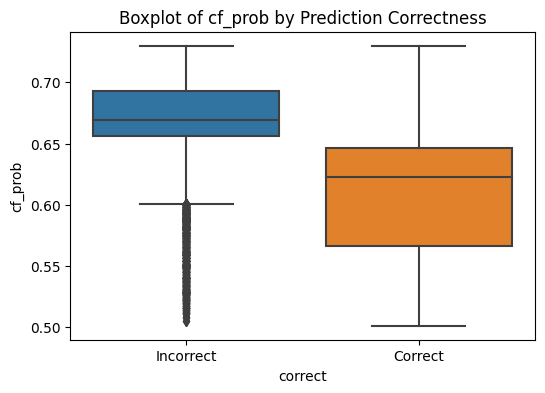

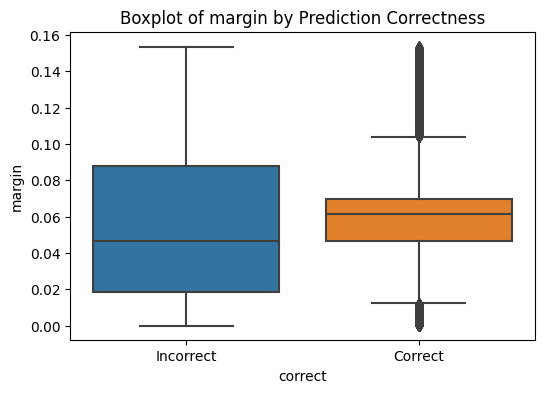

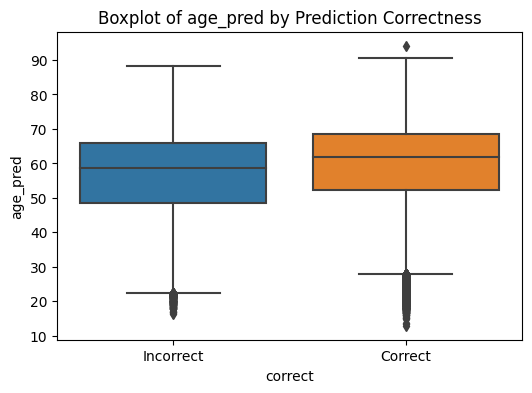

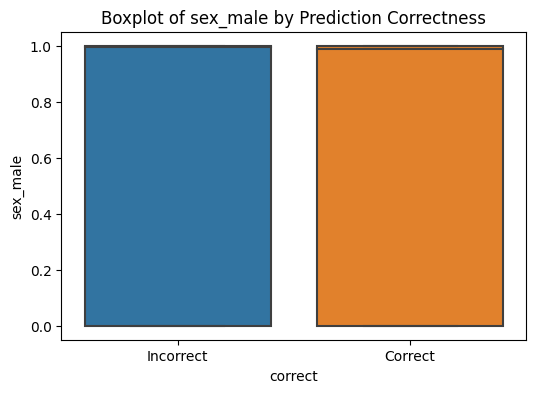

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick a few features to visualize
features_to_plot = feature_cols[:5]  # or your top features / organ aggregates

for f in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='correct', y=f, data=df)
    plt.xticks([0,1], ['Incorrect', 'Correct'])
    plt.title(f'Boxplot of {f} by Prediction Correctness')
    plt.show()

In [24]:
from scipy.stats import mannwhitneyu

p_values = {}
for f in feature_cols:
    stat, p = mannwhitneyu(correct[f], incorrect[f], alternative='two-sided')
    p_values[f] = p

p_df = pd.DataFrame.from_dict(p_values, orient='index', columns=['p_value'])
p_df = p_df.sort_values('p_value')
print(p_df.head(10))

                                                 p_value
Spine_bbox_height                                    0.0
Right Clavicle_original_shape2D_MaximumDiameter      0.0
Right Clavicle_original_shape2D_MeshSurface          0.0
Right Clavicle_original_shape2D_Perimeter            0.0
Right Clavicle_original_shape2D_PixelSurface         0.0
Right Clavicle_original_firstorder_Energy            0.0
Right Clavicle_original_firstorder_Entropy           0.0
Right Clavicle_original_firstorder_Maximum           0.0
Right Clavicle_original_firstorder_Range             0.0
Weasand_original_firstorder_Uniformity               0.0


In [25]:
def cohen_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2) / 2)

effect_sizes = {f: cohen_d(correct[f], incorrect[f]) for f in feature_cols}
effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['cohen_d']).sort_values('cohen_d', key=abs, ascending=False)
print(effect_df.head(10))

                                                     cohen_d
cf_prob                                            -1.274017
effusion_prob                                       1.090333
delta_Heart_original_firstorder_10Percentile        0.847630
delta_Heart_original_firstorder_Mean                0.745429
delta_Heart_original_firstorder_Minimum             0.745318
Heart_original_firstorder_Minimum                   0.740082
delta_Heart_original_firstorder_MeanAbsoluteDev... -0.695410
delta_Heart_original_firstorder_Energy              0.692446
delta_Heart_original_firstorder_TotalEnergy         0.692446
Heart_original_firstorder_Range                    -0.672405


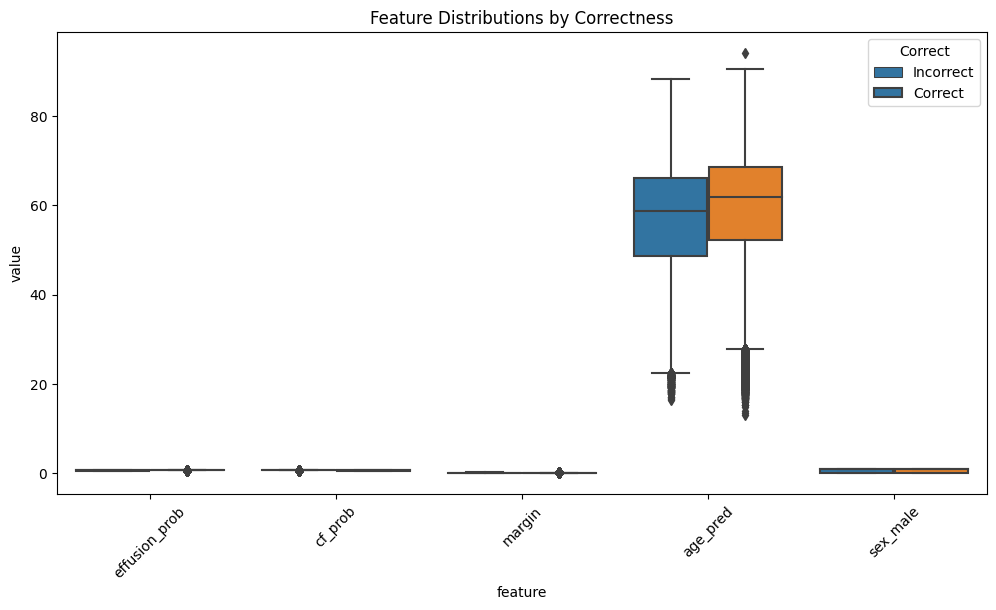

In [26]:
# Melt dataframe for seaborn
melted = df.melt(id_vars='correct', value_vars=features_to_plot, 
                 var_name='feature', value_name='value')

plt.figure(figsize=(12,6))
sns.boxplot(x='feature', y='value', hue='correct', data=melted)
plt.xticks(rotation=45)
plt.legend(title='Correct', labels=['Incorrect', 'Correct'])
plt.title('Feature Distributions by Correctness')
plt.show()

Top 10 most different features: ['cf_prob', 'effusion_prob', 'delta_Heart_original_firstorder_10Percentile', 'delta_Heart_original_firstorder_Mean', 'delta_Heart_original_firstorder_Minimum', 'Heart_original_firstorder_Minimum', 'delta_Heart_original_firstorder_MeanAbsoluteDeviation', 'delta_Heart_original_firstorder_Energy', 'delta_Heart_original_firstorder_TotalEnergy', 'Heart_original_firstorder_Range']


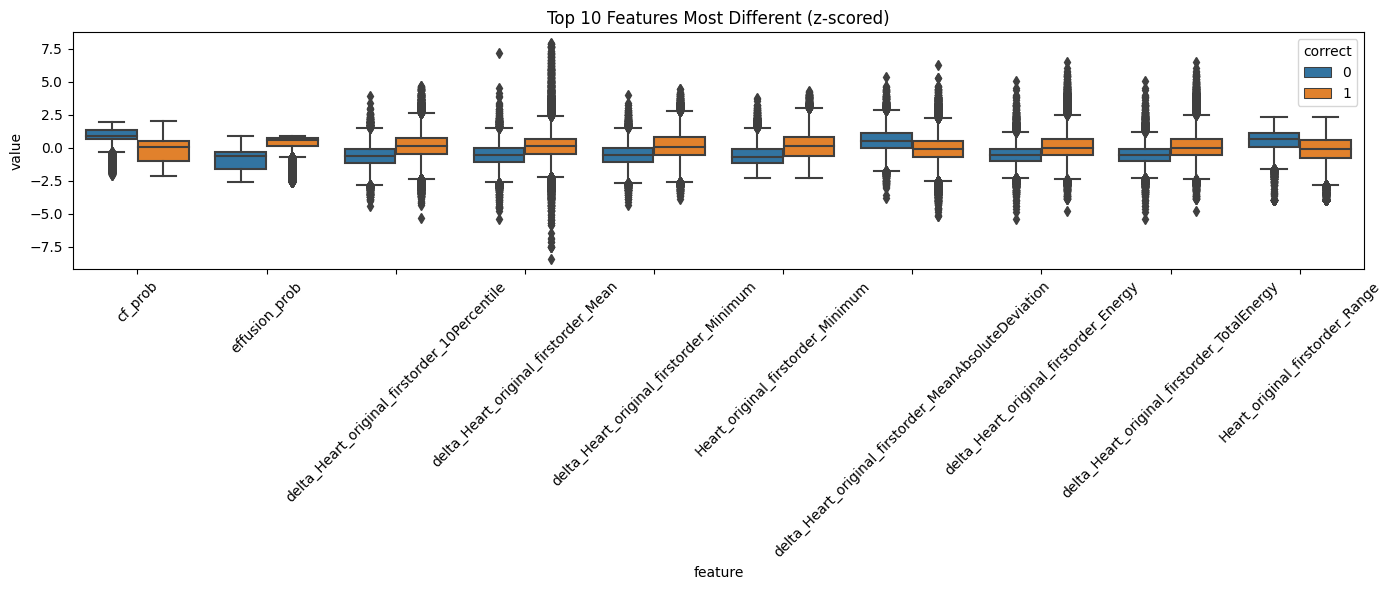

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -----------------------------
# Compute effect sizes (Cohen's d)
# -----------------------------
def cohen_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

effect_sizes = {f: abs(cohen_d(correct[f], incorrect[f])) for f in feature_cols}
effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['cohen_d'])
effect_df = effect_df.sort_values('cohen_d', ascending=False)

top_features = effect_df.head(10).index.tolist()
print("Top 10 most different features:", top_features)

# -----------------------------
# Melt dataframe for plotting
# -----------------------------
melted = df.melt(id_vars='correct', value_vars=top_features, 
                 var_name='feature', value_name='value')

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[top_features] = scaler.fit_transform(df[top_features])

# Now you could melt and plot them together
melted_scaled = df_scaled.melt(id_vars='correct', value_vars=top_features,
                               var_name='feature', value_name='value')

plt.figure(figsize=(14,6))
sns.boxplot(x='feature', y='value', hue='correct', data=melted_scaled)
plt.xticks(rotation=45)
plt.title('Top 10 Features Most Different (z-scored)')
plt.tight_layout()
plt.show()


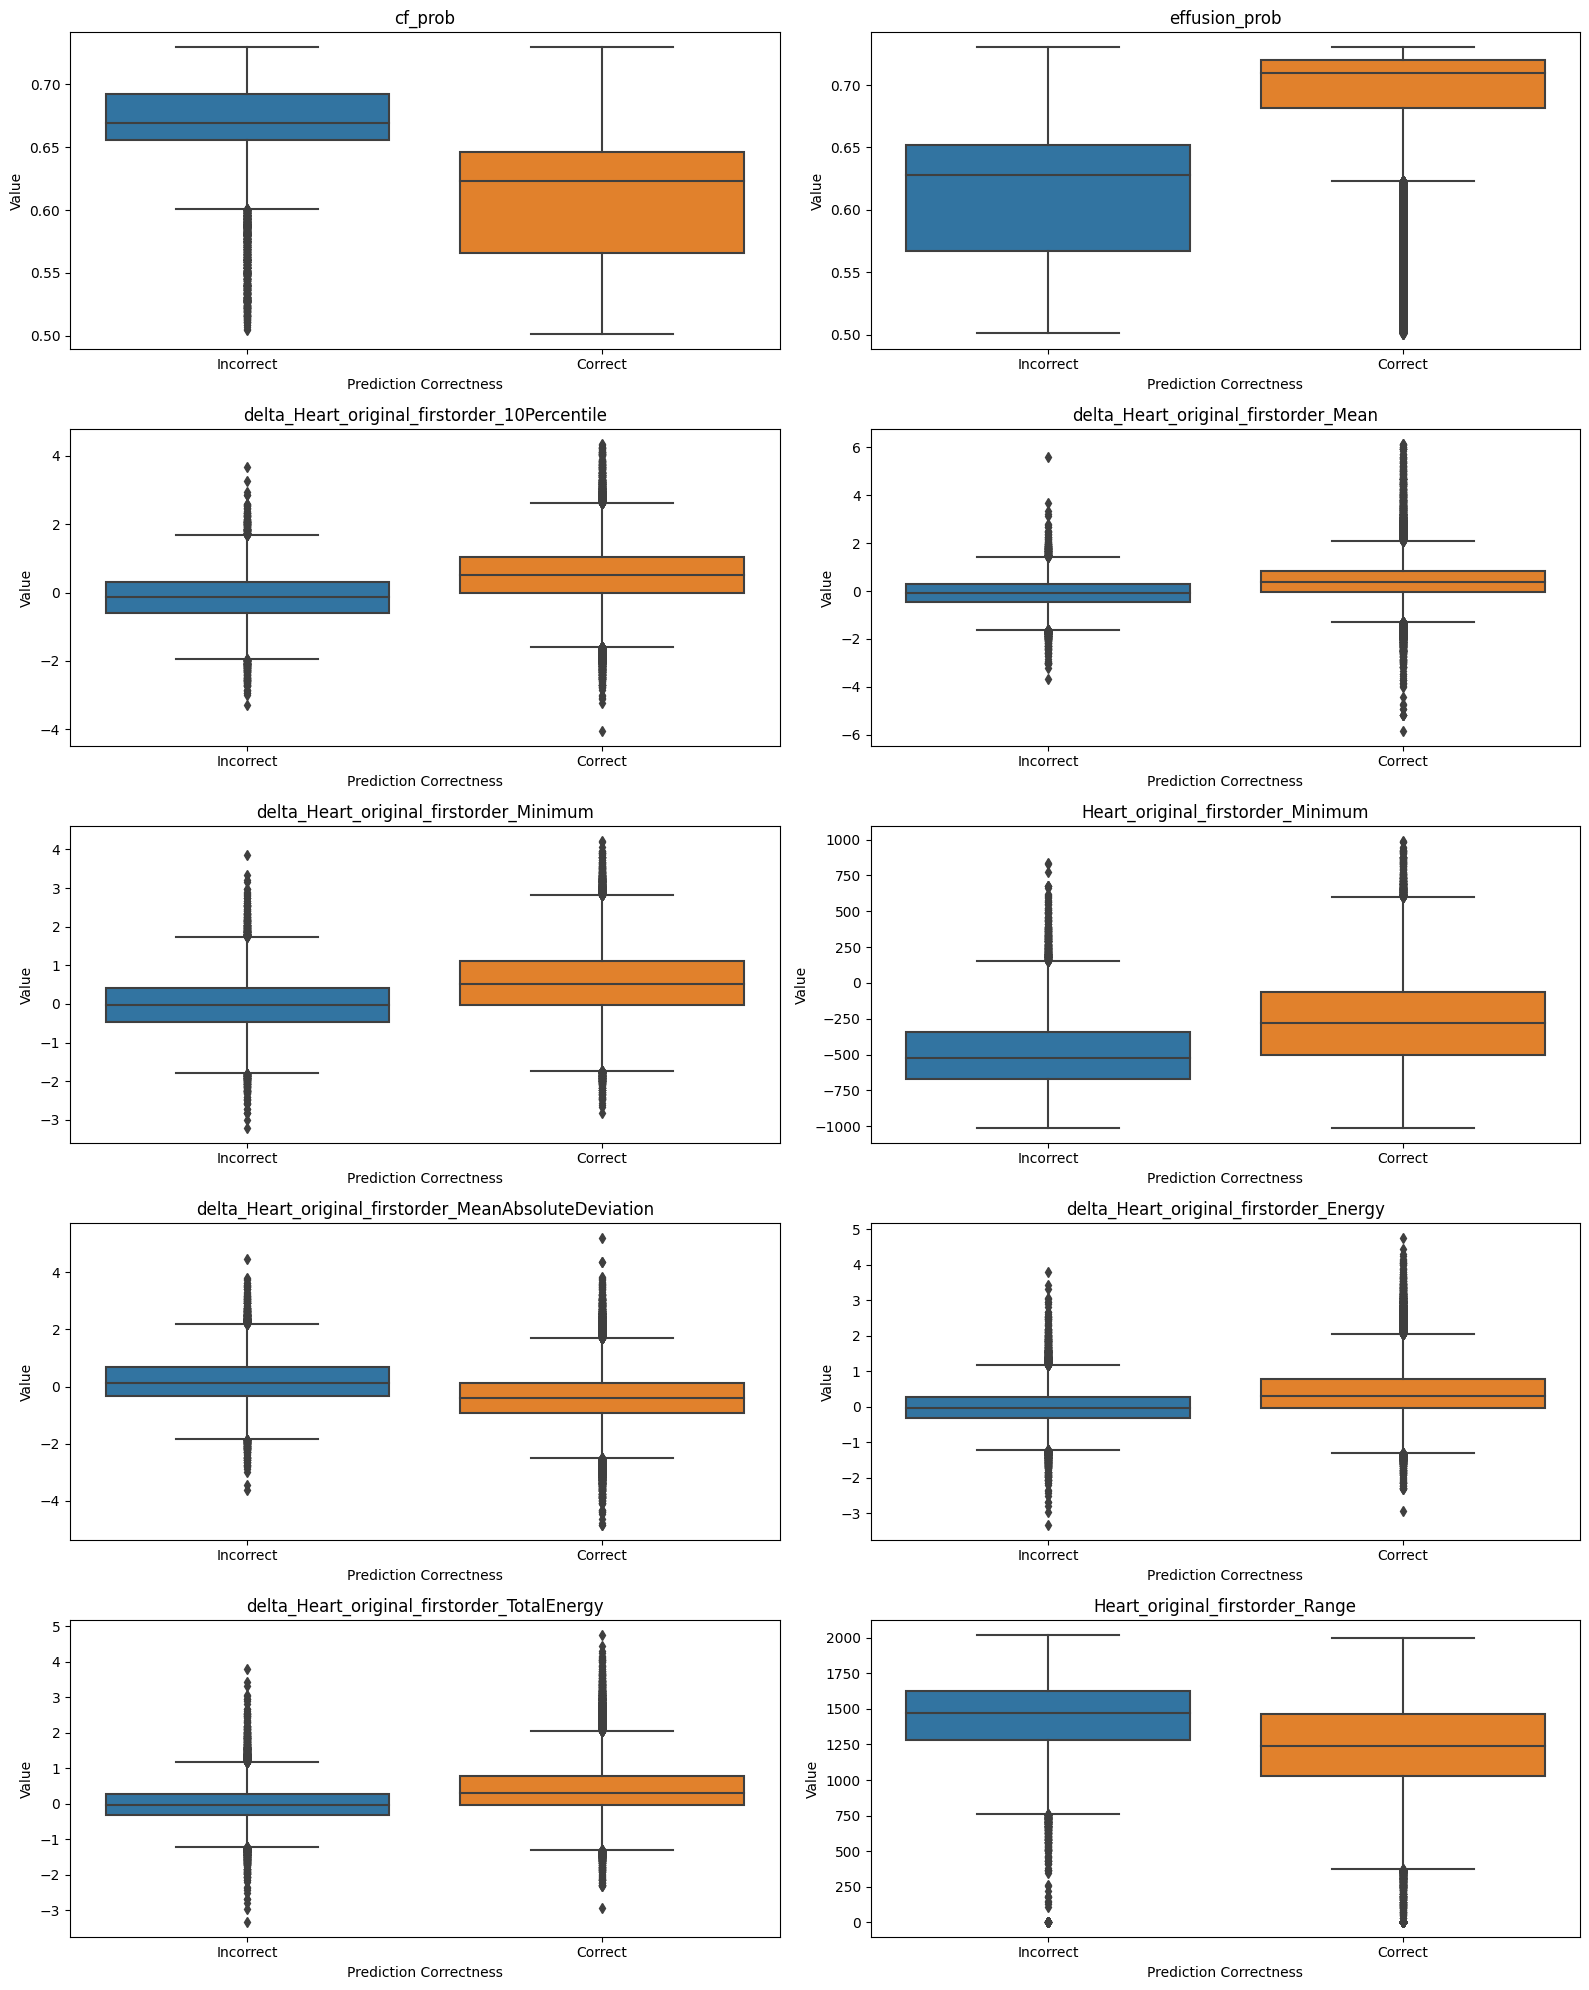

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Choose number of columns in the grid
n_cols = 2
n_features = len(top_features)
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 4*n_rows))
axes = axes.flatten()  # flatten in case grid is 2D

for i, f in enumerate(top_features):
    sns.boxplot(x='correct', y=f, data=df, ax=axes[i])
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['Incorrect', 'Correct'])
    axes[i].set_title(f'{f}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('Prediction Correctness')

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Top 10 organ-feature groups: ['Left Lung - shape', 'Clavicle - shape', 'Scapula - firstorder', 'Scapula - shape', 'Left Lung - firstorder', 'Heart - firstorder', 'Clavicle - firstorder', 'Aorta - shape', 'Aorta - firstorder', 'Right Lung - firstorder']


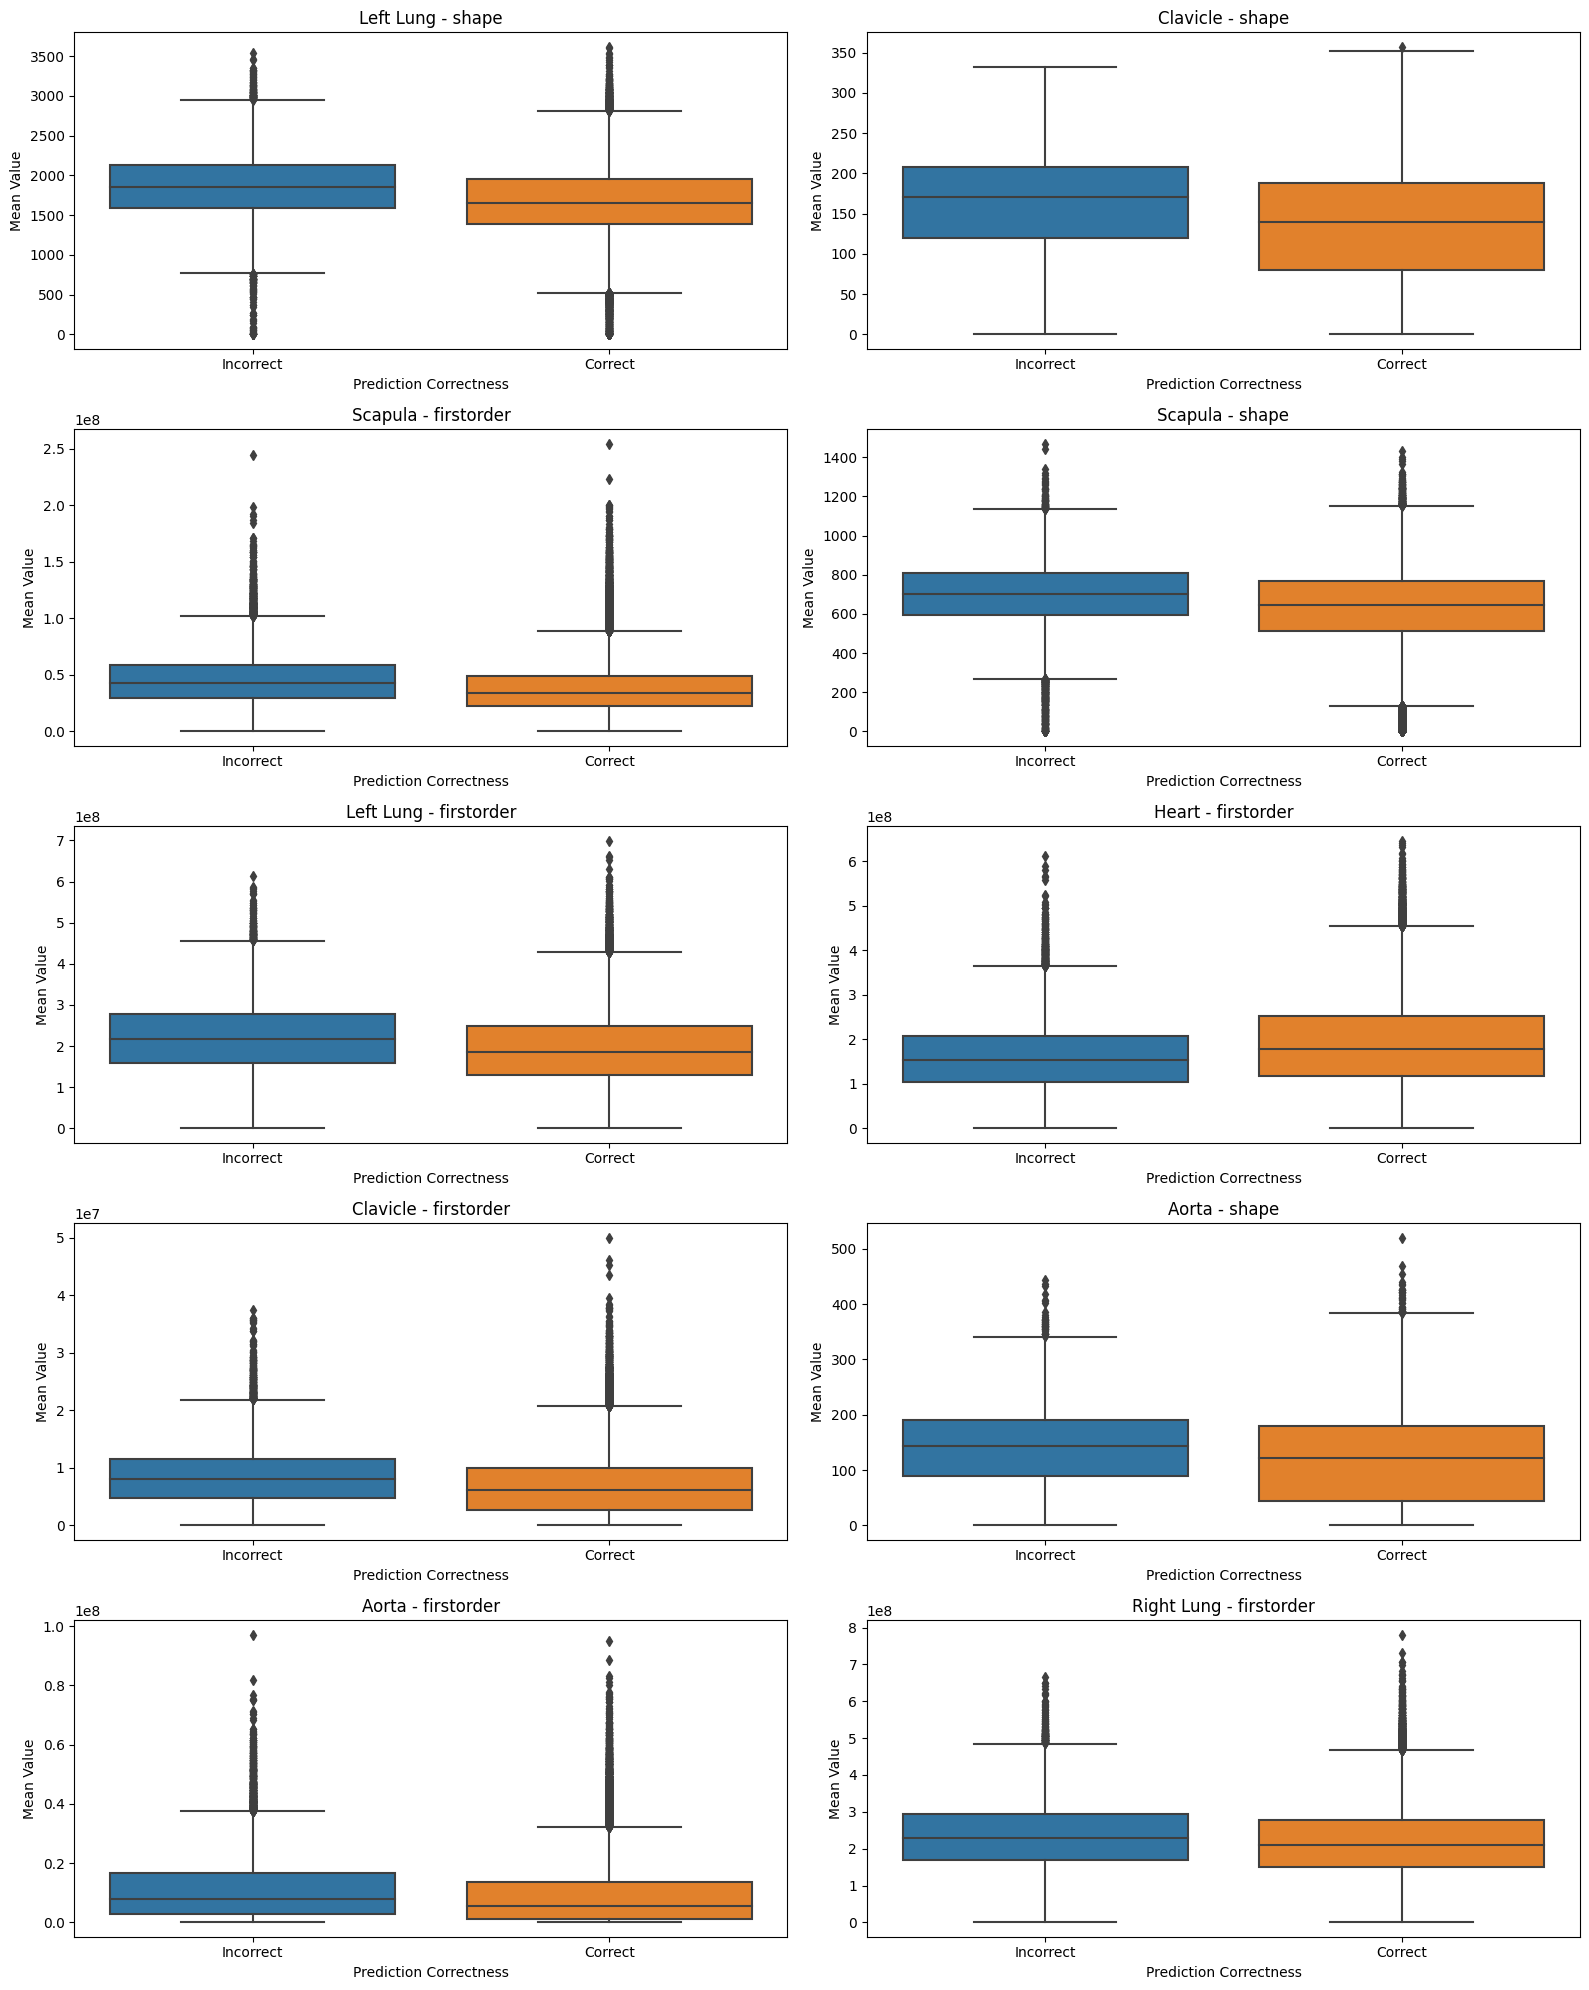

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# -----------------------------
# Example organ-feature type mapping
# -----------------------------
# Assumes your attr_cols have names like "Heart_shape_volume", "Left Lung_texture_entropy"
ORGANS = ['Heart', 'Left Lung', 'Right Lung', 'Aorta', 'Mediastinum', 'Scapula', 'Clavicle']
FEATURE_TYPES = ['shape', 'firstorder', 'texture']  # adjust to match your naming

# Create groups: organ x feature_type
group_dict = {}
for organ in ORGANS:
    for ftype in FEATURE_TYPES:
        # select columns matching both organ and feature type
        cols = [c for c in attr_cols if organ in c and ftype in c.lower()]
        if cols:
            group_name = f"{organ} - {ftype}"
            group_dict[group_name] = cols

# -----------------------------
# Aggregate per sample (mean of each group)
# -----------------------------
for group_name, cols in group_dict.items():
    df[group_name] = df[cols].mean(axis=1)

group_cols = list(group_dict.keys())

# -----------------------------
# Split correct / incorrect
# -----------------------------
correct = df[df['correct']==1]
incorrect = df[df['correct']==0]

# -----------------------------
# Compute Cohen's d for each group
# -----------------------------
def cohen_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

effect_sizes = {g: abs(cohen_d(correct[g], incorrect[g])) for g in group_cols}
effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['cohen_d'])
effect_df = effect_df.sort_values('cohen_d', ascending=False)

top_groups = effect_df.head(10).index.tolist()
print("Top 10 organ-feature groups:", top_groups)

# -----------------------------
# Melt for plotting
# -----------------------------
melted = df.melt(id_vars='correct', value_vars=top_groups, 
                 var_name='group', value_name='value')

# -----------------------------
# Plot subplots in one figure
# -----------------------------
n_cols = 2
n_rows = math.ceil(len(top_groups)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 4*n_rows))
axes = axes.flatten()

for i, g in enumerate(top_groups):
    sns.boxplot(x='correct', y=g, data=df, ax=axes[i])
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['Incorrect', 'Correct'])
    axes[i].set_title(g)
    axes[i].set_ylabel('Mean Value')
    axes[i].set_xlabel('Prediction Correctness')

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Top 10 delta features: ['delta_Heart_original_firstorder_10Percentile', 'delta_Heart_original_firstorder_Mean', 'delta_Heart_original_firstorder_Minimum', 'delta_Heart_original_firstorder_MeanAbsoluteDeviation', 'delta_Heart_original_firstorder_TotalEnergy', 'delta_Heart_original_firstorder_Energy', 'delta_Heart_original_firstorder_Range', 'delta_Heart_original_firstorder_Variance', 'delta_Heart_original_firstorder_RootMeanSquared', 'delta_Heart_original_firstorder_RobustMeanAbsoluteDeviation']


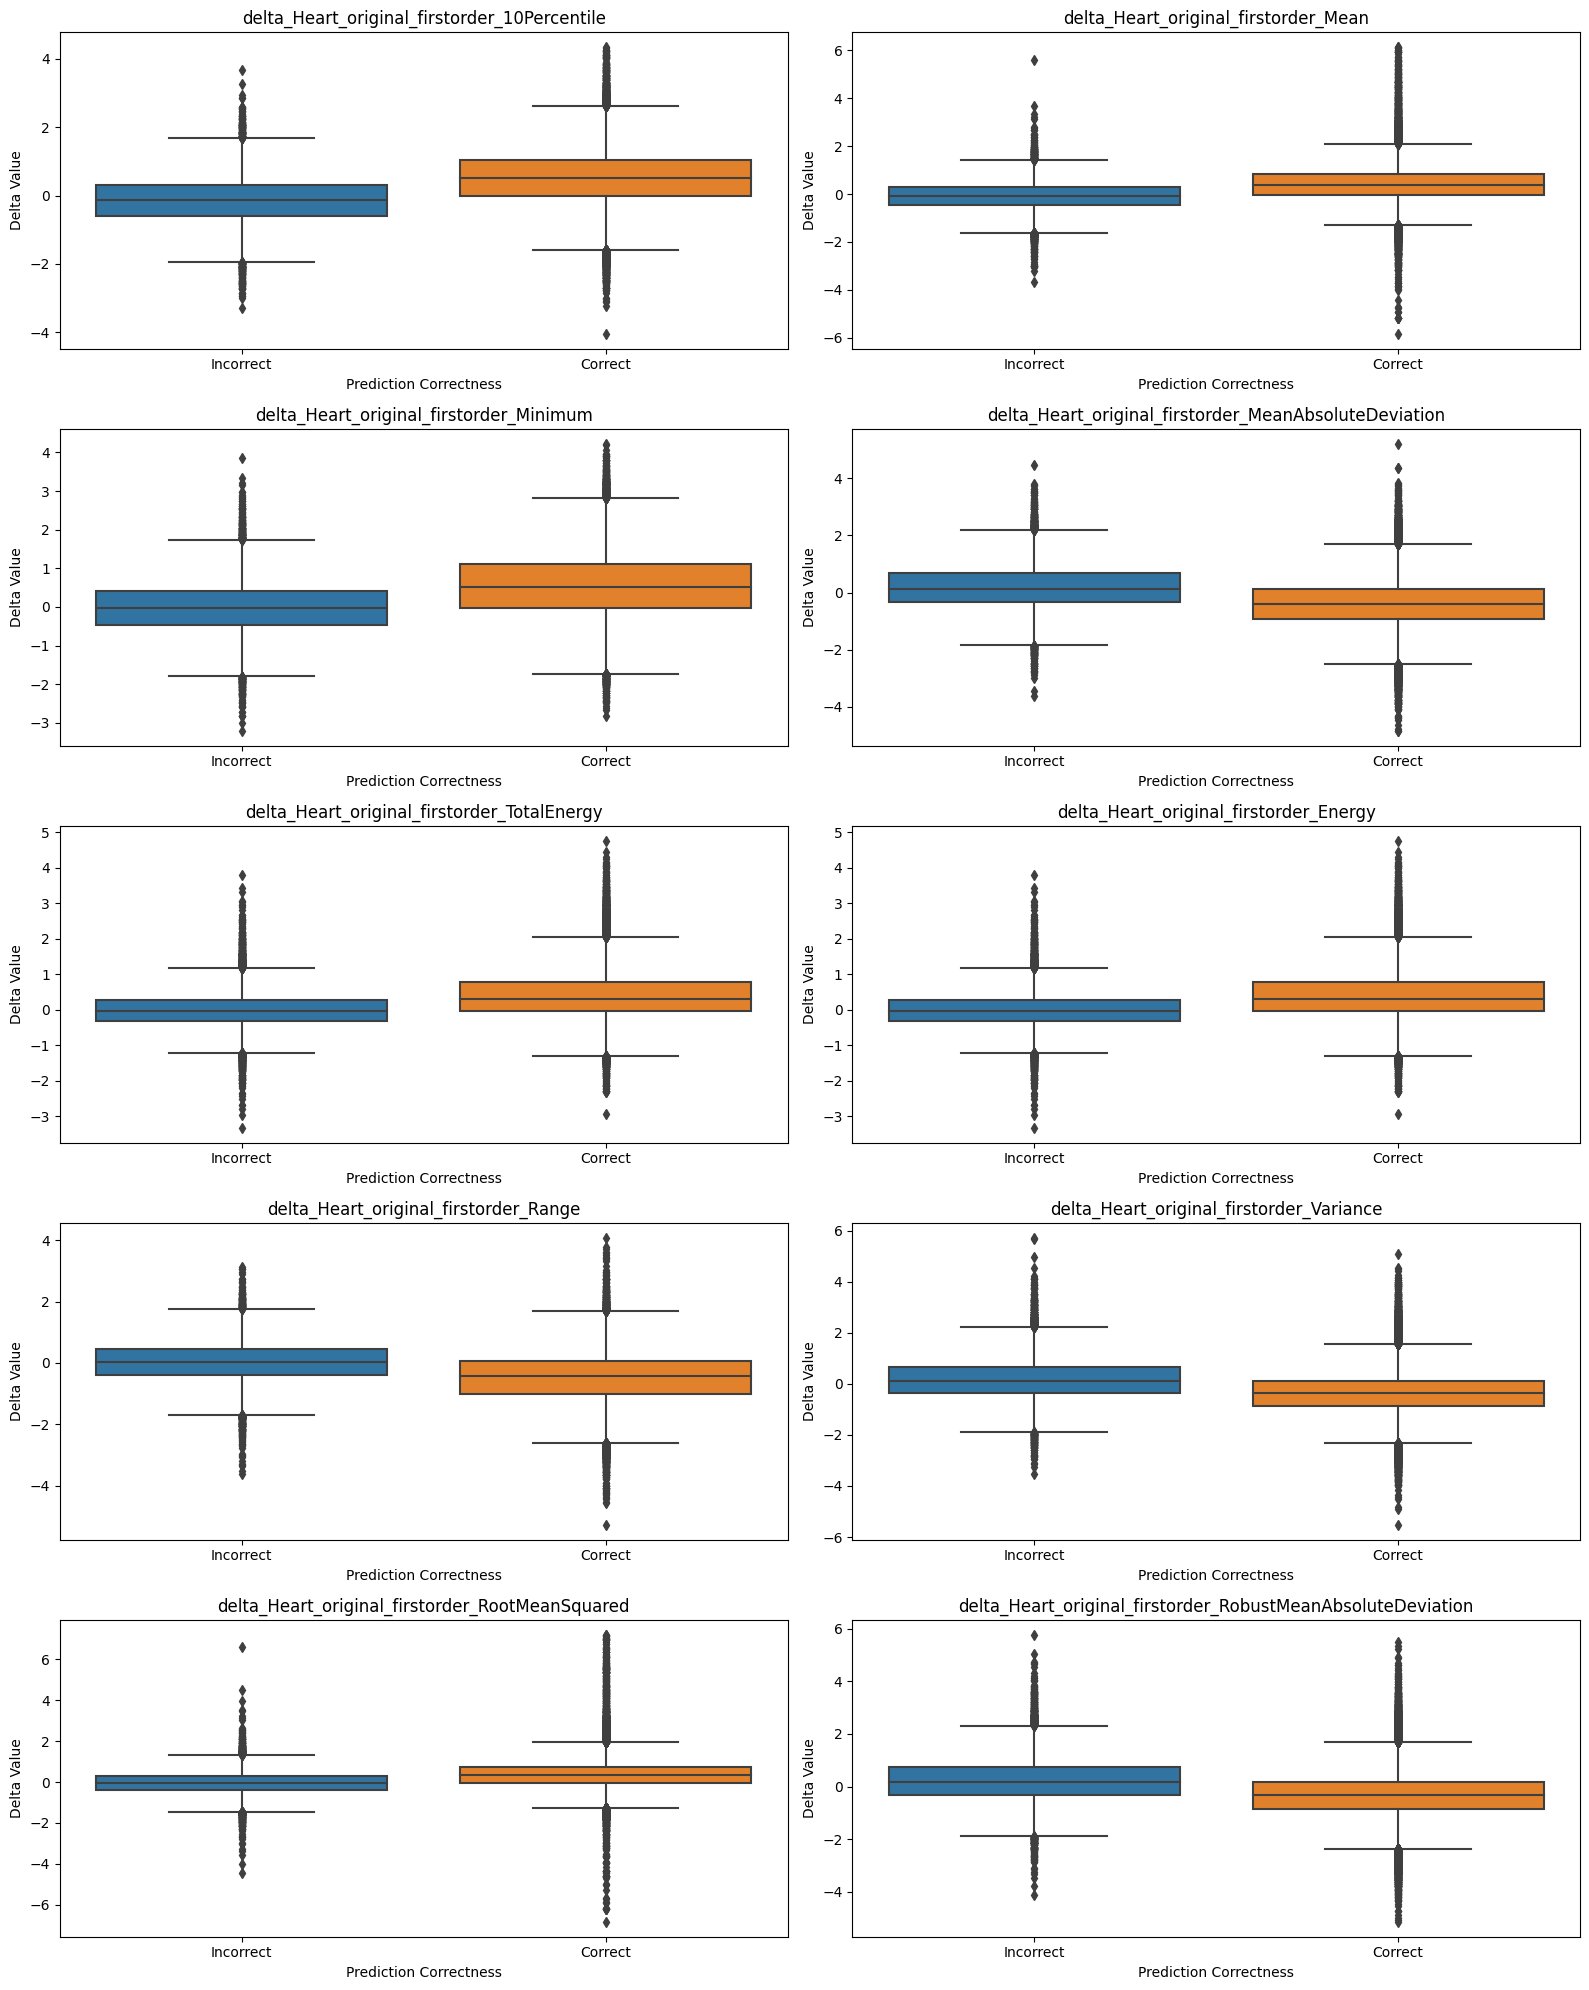

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# -----------------------------
# Compute Cohen's d for delta features
# -----------------------------
def cohen_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

effect_sizes = {f: abs(cohen_d(correct[f], incorrect[f])) for f in delta_cols}
effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['cohen_d'])
effect_df = effect_df.sort_values('cohen_d', ascending=False)

top_deltas = effect_df.head(10).index.tolist()
print("Top 10 delta features:", top_deltas)

# -----------------------------
# Plot subplots in one figure
# -----------------------------
n_cols = 2
n_rows = math.ceil(len(top_deltas)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 4*n_rows))
axes = axes.flatten()

for i, f in enumerate(top_deltas):
    sns.boxplot(x='correct', y=f, data=df, ax=axes[i])
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['Incorrect', 'Correct'])
    axes[i].set_title(f)
    axes[i].set_ylabel('Delta Value')
    axes[i].set_xlabel('Prediction Correctness')

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()